In [62]:
import pandas as pd
import numpy as np
from datetime import date
from dateutil.relativedelta import relativedelta
import os
from tqdm import tqdm
from collections import Counter
from transformers import (
  AutoTokenizer,
  AutoModel,
)
import torch

In [63]:
import pickle
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from collections import Counter
from tqdm import tqdm

import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

# Load Data and Embedding Dataset of tsmc

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
def load_df(filepath, preview=True):
    print(f"\n----- Loading {filepath}... -----")
    df = pd.read_csv(filepath)
    print(f"Size of dataframe: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    if preview:
        print(df.head())
    return df

In [66]:
folder_path = '/content/drive/MyDrive/bda2024_mid_dataset/'

news1_df = load_df(folder_path+"bda2024_202203-202402_內容數據_新聞1.csv", preview=False)
news2_df = load_df(folder_path+"bda2024_202203-202402_內容數據_新聞2.csv", preview=False)
news3_df = load_df(folder_path+"bda2024_202203-202402_內容數據_新聞3.csv", preview=False)
disc_ptt_df = load_df(folder_path+"bda2024_202203-202402_討論數據_ptt.csv", preview=False)

noreply_df = pd.concat([news1_df, news2_df, news3_df, disc_ptt_df], ignore_index=True)

disc_dcard_df = load_df(folder_path+"bda2024_202203-202402_討論數據_dcard.csv", preview=False)
disc_dcard_df.rename(columns={'forum': 'p_type'}, inplace=True)    # Repair column name typo in data
disc_m1_df = load_df(folder_path+"bda2024_202203-202402_討論數據_mobile01-1.csv", preview=False)
disc_m2_df = load_df(folder_path+"bda2024_202203-202402_討論數據_mobile01-2.csv", preview=False)

url_pattern_m = r't=(\d+)'
url_pattern_d = r'p/(\d+)'
disc_m1_df['thread_id'] = disc_m1_df['page_url'].str.extract(url_pattern_m)
disc_m2_df['thread_id'] = disc_m2_df['page_url'].str.extract(url_pattern_m)
disc_dcard_df['thread_id'] = disc_dcard_df['page_url'].str.extract(url_pattern_d)

reply_df = pd.concat([disc_dcard_df, disc_m1_df, disc_m2_df], ignore_index=True)

transaction_df = load_df(folder_path+"bda2024_微股力_個股交易數據-2年.csv", preview=False)
report_df = load_df(folder_path+"bda2024_微股力_財報數據-2年.csv", preview=False)
chip_df = load_df(folder_path+"bda2024_微股力_籌碼數據-2年.csv", preview=False)
transaction_df['stock_symbol'] = transaction_df['stock_symbol'].astype(str)
chip_df['stock_symbol'] = chip_df['stock_symbol'].astype(str)    # Repair mixed data types


----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_內容數據_新聞1.csv... -----
Size of dataframe: (179449, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_內容數據_新聞2.csv... -----
Size of dataframe: (15114, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_內容數據_新聞3.csv... -----
Size of dataframe: (290929, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_202203-202402_討論數據_ptt.csv... -----
Size of dataframe: (50805, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']

----- Loading /content/drive/MyDrive/bda2024_

<ipython-input-65-3ba66dfef298>:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Size of dataframe: (1154225, 8)
Columns: ['stock_name', 'stock_symbol', 'open', 'high', 'low', 'close', 'volume', 'date']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_微股力_財報數據-2年.csv... -----
Size of dataframe: (16482, 16)
Columns: ['stock_name', 'stock_symbol', 'period', 'gross_profit_margin', 'operating_profit_margin', 'net_profit_margin', 'return_on_equity', 'debt_ratio', 'interest_coverage', 'current_ratio', 'quick_ratio', 'accounts_turnover', 'inventory_turnover', 'eps', 'book_value_per_share', 'date']

----- Loading /content/drive/MyDrive/bda2024_mid_dataset/bda2024_微股力_籌碼數據-2年.csv... -----


<ipython-input-65-3ba66dfef298>:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Size of dataframe: (998031, 9)
Columns: ['stock_name', 'stock_symbol', 'foreign_investor_bought', 'foreign_investor_sold', 'investment_trust_bought', 'investment_trust_sold', 'dealer_bought', 'dealer_sold', 'date']


In [67]:
all_text_data = pd.read_csv('/content/drive/MyDrive/merged_embeddings_tsmc.csv')
all_text_data.head()

,0,1,2,3,4,5,6,7,8,9,...,782,783,784,785,786,787,788,789,790,791
0,2022-03-01,台積電,2022-03-01,2330,33868510,59393909,733000,92000,2206457,827796,...,0.766458,-0.301630,0.206771,-0.236764,0.039337,-0.591708,-0.465070,0.424499,-0.251579,-0.231501
1,2022-03-01,台積電,2022-03-01,2330,33868510,59393909,733000,92000,2206457,827796,...,0.748023,0.200840,-0.105250,-0.214787,-0.147682,-0.956461,-0.167647,0.099332,-0.408404,-0.208983
2,2022-03-01,台積電,2022-03-01,2330,33868510,59393909,733000,92000,2206457,827796,...,0.520980,-0.231023,0.131039,-0.280313,0.490919,-0.824481,-0.045931,0.198517,-0.364945,-0.279433
3,2022-03-01,台積電,2022-03-01,2330,33868510,59393909,733000,92000,2206457,827796,...,0.029969,-0.684525,-0.451997,-0.375910,1.236042,-0.861707,0.227966,0.335897,-0.155650,-0.476788
4,2022-03-01,台積電,2022-03-01,2330,33868510,59393909,733000,92000,2206457,827796,...,0.374595,0.208070,0.219262,-0.260578,0.724344,-0.762172,-0.575515,0.250037,-0.385322,-0.145293


In [68]:
# all_text_data = all_text_data.drop(all_text_data.columns[2], axis=1)
# all_text_data.head()

# Prepare Training and Testing Dataset (分看漲、看跌)

In [69]:
# Parameter Setting
stock_name = "台積電"
n_days_after = 4
# threshold = 0.03
dates_train = (datetime(2022, 9, 1).date(), datetime(2022, 11, 30).date())
dates_test = (datetime(2022, 12, 1).date(), datetime(2022, 12, 31).date())

In [70]:
all_text_data[all_text_data.columns[0]]

0        2022-03-01
1        2022-03-01
2        2022-03-01
3        2022-03-01
4        2022-03-01
            ...    
38573    2023-09-17
38574    2023-09-17
38575    2022-12-01
38576    2022-12-01
38577    2022-11-07
Name: 0, Length: 38578, dtype: object

In [71]:
all_text_data[all_text_data.columns[0]] = pd.to_datetime(all_text_data[all_text_data.columns[0]]).dt.date

date_train_start, date_train_end = dates_train
date_test_start, date_test_end = dates_test

df_train = all_text_data[(all_text_data[all_text_data.columns[0]] >= date_train_start) & (all_text_data[all_text_data.columns[0]] <= date_train_end)]
df_train = df_train.sort_values(by=df_train.columns[0])
df_test = all_text_data[(all_text_data[all_text_data.columns[0]] >= date_test_start) & (all_text_data[all_text_data.columns[0]] <= date_test_end)]
df_test = df_test.sort_values(by=df_test.columns[0])
df_test

,0,1,2,3,4,5,6,7,8,9,...,782,783,784,785,786,787,788,789,790,791
1638,2022-12-01,台積電,2022-12-01,2330,25955719,14034014,456000,165000,434737,2908498,...,0.692810,-0.411797,0.225816,-0.375065,0.630494,-1.056808,-0.249823,0.040975,-0.423314,-0.097422
20133,2022-12-01,台積電,2022-12-01,2330,25955719,14034014,456000,165000,434737,2908498,...,0.029971,0.301886,0.716459,-0.022031,-0.027507,-0.756201,-0.414386,0.168059,-0.562854,0.114953
20134,2022-12-01,台積電,2022-12-01,2330,25955719,14034014,456000,165000,434737,2908498,...,0.517883,0.009583,-0.077727,0.087236,0.753758,-0.731965,-0.306861,-0.063165,-0.752780,-0.080539
20135,2022-12-01,台積電,2022-12-01,2330,25955719,14034014,456000,165000,434737,2908498,...,0.558394,0.385500,0.862497,-0.110535,0.133461,-0.343688,-0.486246,0.418188,-0.584731,0.020562
20136,2022-12-01,台積電,2022-12-01,2330,25955719,14034014,456000,165000,434737,2908498,...,0.801254,-0.103737,0.465539,-0.138385,0.005500,-0.441675,-0.691845,0.458556,-0.375884,0.009440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36326,2022-12-31,台積電,2023-01-03,2330,6991006,8025553,279000,50000,761224,814945,...,0.640775,0.091733,0.161506,-0.134078,0.492699,-0.892876,-0.576642,0.399000,0.068699,-0.068917
36327,2022-12-31,台積電,2023-01-03,2330,6991006,8025553,279000,50000,761224,814945,...,0.901484,0.050882,0.345854,-0.090083,0.306002,-0.499372,-0.505524,0.094595,-0.085820,-0.078865
36328,2022-12-31,台積電,2023-01-03,2330,6991006,8025553,279000,50000,761224,814945,...,0.682168,0.311594,-0.063065,-0.747217,0.300963,-0.535117,-0.164974,-0.066670,-0.079357,-0.190775
36319,2022-12-31,台積電,2023-01-03,2330,6991006,8025553,279000,50000,761224,814945,...,0.365446,-0.127863,-0.138642,-0.436968,0.059202,-0.721500,-0.339917,0.743230,-0.347471,-0.175532


In [72]:
#ase = stock[stock['stock_symbol'].str.contains('2303')]
#ase['年月日'] = pd.to_datetime(ase['年月日']).dt.date #將日期的時間部分去除
def categorize_label(x):
  threshold = 0.007
  if x >= threshold:
    return 1
  elif x <= -threshold:
    return -1
  else:
    return 0

transaction_df['date'] = pd.to_datetime(transaction_df ['date']).dt.date #將日期的時間部分去除
transaction_df = transaction_df.sort_values(by = 'date').reset_index(drop = True)

# 計算各股票的單日漲跌幅度
tsmc_df = transaction_df[transaction_df['stock_name'] == '台積電']
tsmc_df['percent_change'] = np.nan
tsmc_df['label'] = np.nan
cnt = 0
for i, row in tsmc_df.iterrows():
  if cnt == 0:
    prev = row['close']
    cnt += 1
    continue
  percent_change = (row['close'] - prev) / prev
  #print(percent_change)
  tsmc_df.at[i, 'percent_change'] = percent_change
  tsmc_df.at[i, 'label'] = categorize_label(percent_change)
  prev = row['close']
tsmc_df

<ipython-input-72-b7e66e3e1850>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsmc_df['percent_change'] = np.nan
<ipython-input-72-b7e66e3e1850>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsmc_df['label'] = np.nan


,stock_name,stock_symbol,open,high,low,close,volume,date,percent_change,label
1502,台積電,2330,599.0,610.0,599.0,604.0,70304,2022-03-01,NaN,NaN
3552,台積電,2330,601.0,605.0,600.0,601.0,42428,2022-03-02,-0.004967,0.0
6115,台積電,2330,603.0,607.0,601.0,602.0,37104,2022-03-03,0.001664,0.0
7566,台積電,2330,595.0,597.0,592.0,595.0,65235,2022-03-04,-0.011628,-1.0
9112,台積電,2330,580.0,581.0,575.0,576.0,97168,2022-03-07,-0.031933,-1.0
...,...,...,...,...,...,...,...,...,...,...
1141873,台積電,2330,675.0,688.0,675.0,687.0,31404,2024-02-20,0.013274,1.0
1146325,台積電,2330,678.0,683.0,678.0,681.0,31981,2024-02-21,-0.008734,-1.0
1147469,台積電,2330,695.0,695.0,685.0,692.0,34269,2024-02-22,0.016153,1.0
1151618,台積電,2330,701.0,703.0,696.0,697.0,48404,2024-02-23,0.007225,1.0


In [73]:
value_counts = tsmc_df['label'].value_counts()
value_counts

label
 0.0    182
-1.0    153
 1.0    149
Name: count, dtype: int64

In [74]:
# Prepare X_train and y_train
from sklearn.preprocessing import MinMaxScaler

y_train = []

# Match row in df_train with its label using (post_date + n_days_after == label's date)
for i in range(len(df_train)):
  d = df_train.iloc[i][0]
  d += timedelta(days=n_days_after)
  # add one day until the date exists in tsmc_df (處理非營業日)
  while d not in tsmc_df['date'].values: d += timedelta(days=1)
  y_train.append(tsmc_df[tsmc_df['date']==d]['label'])

# Reshape
y_train = np.array(y_train)[:, 0]
df_train = df_train.drop(columns=df_train.columns[:24])
columns_to_drop = df_train.select_dtypes(exclude=['float', 'int']).columns
df_train = df_train.drop(columns=columns_to_drop)

# Min-Max Normalization
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_train)
X_train = np.atleast_2d(scaled_data)
# X_train = np.atleast_2d(df_train.values.tolist())

In [75]:
# df_train

In [76]:
# df_test

In [77]:
# Tried oversampling to reduce class imbalance, but the results did not improve
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

print("Class distribution before balancing:")
print("Class -1:", sum(y_train == -1))
print("Class 0:", sum(y_train == 0))
print("Class 1:", sum(y_train == 1))

# ros = RandomOverSampler(random_state=42)
# X_train, y_train = ros.fit_resample(X_train, y_train)

# print("\nClass distribution after balancing with RandomOverSampler:")
# print("Class -1:", sum(y_train == -1))
# print("Class 0:", sum(y_train == 0))
# print("Class 1:", sum(y_train == 1))

# rus = RandomUnderSampler(random_state=42)
# X_train, y_train = rus.fit_resample(X_train, y_train)

# # Class distribution after balancing
# print("\nClass distribution after balancing with RandomUnderSampler:")
# print("Class -1:", sum(y_train == -1))
# print("Class 0:", sum(y_train == 0))
# print("Class 1:", sum(y_train == 1))

Class distribution before balancing:
Class -1: 3792
Class 0: 1147
Class 1: 2426


In [78]:
# y = []
# df_X = all_text_data[(all_text_data[all_text_data.columns[0]] >= date_train_start) & (all_text_data[all_text_data.columns[0]] <= date_test_end)]
# df_X = df_X.sort_values(by=df_X.columns[0])

# for i in range(len(df_X)):
#   d = df_X.iloc[i][0]
#   d += timedelta(days=n_days_after)
#   while d not in tsmc_df['date'].values: d += timedelta(days=1)
#   y.append(tsmc_df[tsmc_df['date']==d]['label'])

# y = np.array(y)[:, 0]
# df_X = df_X.drop(columns=df_X.columns[:4])
# columns_to_drop = df_X.select_dtypes(exclude=['float', 'int']).columns
# df_X = df_X.drop(columns=columns_to_drop)
# X = np.atleast_2d(df_X.values.tolist())

In [79]:
# from sklearn.model_selection import train_test_split
# # Split the dataset into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Print class distribution in the original dataset and the splits
# print("Original class distribution:")
# print("Class 0:", np.sum(y == 0))
# print("Class 1:", np.sum(y == 1))
# print("Class -1:", np.sum(y == -1))
# print()
# print("Training set class distribution:")
# print("Class 0:", np.sum(y_train == 0))
# print("Class 1:", np.sum(y_train == 1))
# print("Class -1:", np.sum(y_train == -1))
# print()
# print("Testing set class distribution:")
# print("Class 0:", np.sum(y_test == 0))
# print("Class 1:", np.sum(y_test == 1))
# print("Class -1:", np.sum(y_test == -1))

In [80]:
# y_train = []

# for i in range(len(df_train)):
#   d = df_train.iloc[i][0]
#   d += timedelta(days=n_days_after)
#   while d not in tsmc_df['date'].values: d += timedelta(days=1)
#   y_train.append(tsmc_df[tsmc_df['date']==d]['label'])

In [81]:
# y_train = np.array(y_train)[:, 0]

In [82]:
# from collections import Counter
# counts = Counter(y_test)

# # Print unique values and their counts
# for value, count in counts.items():
#     print(f"{value}: {count}")

In [83]:
# df_train = df_train.drop(columns=df_train.columns[:4])
# columns_to_drop = df_train.select_dtypes(exclude=['float', 'int']).columns
# df_train = df_train.drop(columns=columns_to_drop)
# X_train = np.atleast_2d(df_train.values.tolist())

In [84]:
# Prepare X_test and y_test, same as X_train and y_train

y_test = []

for i in range(len(df_test)):
  d = df_test.iloc[i][0]
  d += timedelta(days=n_days_after)
  while d not in tsmc_df['date'].values: d += timedelta(days=1)
  y_test.append(tsmc_df[tsmc_df['date']==d]['label'])

y_test = np.array(y_test)[:, 0]

df_test = df_test.drop(columns=df_test.columns[:24])
columns_to_drop = df_test.select_dtypes(exclude=['float', 'int']).columns
df_test = df_test.drop(columns=columns_to_drop)

scaled_data = scaler.fit_transform(df_test)
X_test = np.atleast_2d(scaled_data)
# X_test = np.atleast_2d(df_test.values.tolist())

In [85]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(7365, 768)
(7365,)
(2121, 768)
(2121,)


In [86]:
# X_train[0]

In [87]:
# y_train[:50]

In [88]:
# xgb

import xgboost as xgb
from sklearn.metrics import accuracy_score

# Train XGBoost model
# dtrain = xgb.DMatrix(X_train, label=y_train+1)
# dtest = xgb.DMatrix(X_test, label=y_test+1)
# params = {'objective': 'multi:softmax',  # Use multi-class softmax objective
#     'num_class': 3,  # Number of classes in the dataset
#     'eval_metric': 'mlogloss'  # Evaluation metric: classification error
#           }
# model = xgb.train(params=params, dtrain=dtrain)

# # Predict on test set
# y_pred_proba = model.predict(dtest)
# y_pred_xgb = (y_pred_proba > 0.5).astype(int)

xgb_clf = xgb.XGBClassifier()

xgb_clf.fit(X_train, y_train+1)

y_pred_xgb = xgb_clf.predict(X_test)

              precision    recall  f1-score   support

        -1.0       0.62      0.68      0.65      1315
         0.0       0.09      0.01      0.01       317
         1.0       0.25      0.34      0.29       489

    accuracy                           0.50      2121
   macro avg       0.32      0.34      0.32      2121
weighted avg       0.46      0.50      0.47      2121

Accuracy of xgb: 0.5030645921735031


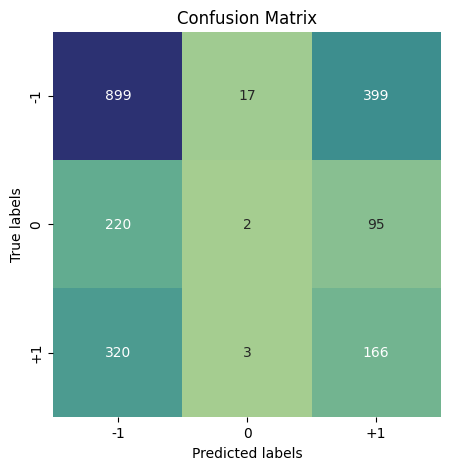

In [89]:
# Evaluate model
print(classification_report(y_test, y_pred_xgb-1))
accuracy = accuracy_score(y_test, y_pred_xgb-1)
print("Accuracy of xgb:", accuracy)
cm = confusion_matrix(y_test, y_pred_xgb-1)
class_labels = ['-1', '0', '+1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

In [91]:
# MLP Classifier

model = MLPClassifier(hidden_layer_sizes=(180, 36), max_iter=300)
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)

              precision    recall  f1-score   support

        -1.0       0.62      0.91      0.74      1315
         0.0       0.17      0.06      0.09       317
         1.0       0.32      0.05      0.09       489

    accuracy                           0.59      2121
   macro avg       0.37      0.34      0.31      2121
weighted avg       0.49      0.59      0.49      2121

Accuracy of MLPClassifier: 0.5875


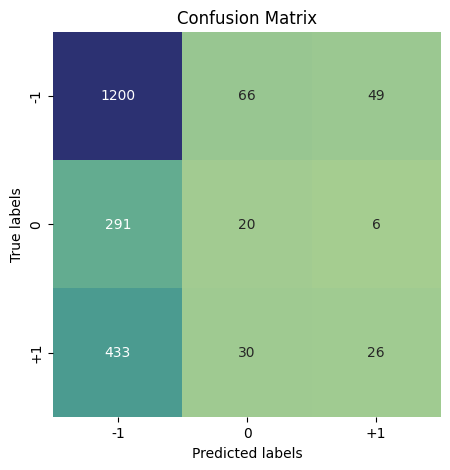

In [92]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy of MLPClassifier: {accuracy:.4f}")
cm = confusion_matrix(y_test, y_test_pred)
class_labels = ['-1', '0', '+1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

In [93]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train+1)
y_pred = clf.predict(X_test)

              precision    recall  f1-score   support

        -1.0       0.62      0.77      0.69      1315
         0.0       0.00      0.00      0.00       317
         1.0       0.24      0.22      0.23       489

    accuracy                           0.53      2121
   macro avg       0.28      0.33      0.31      2121
weighted avg       0.44      0.53      0.48      2121

Accuracy of Random Forest: 0.5318246110325319


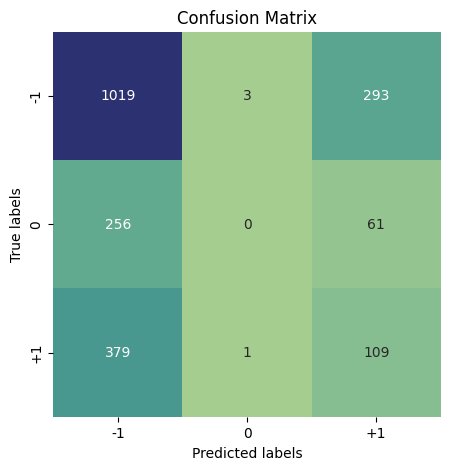

In [94]:
print(classification_report(y_test, y_pred-1))
accuracy = accuracy_score(y_test, y_pred-1)
print("Accuracy of Random Forest:", accuracy)
cm = confusion_matrix(y_test, y_pred-1)
class_labels = ['-1', '0', '+1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

In [95]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred_DT = clf.predict(X_test)

              precision    recall  f1-score   support

        -1.0       0.65      0.47      0.54      1315
         0.0       0.17      0.26      0.21       317
         1.0       0.24      0.34      0.28       489

    accuracy                           0.41      2121
   macro avg       0.35      0.36      0.34      2121
weighted avg       0.48      0.41      0.43      2121

Accuracy of Decision Tree: 0.40782649693540785


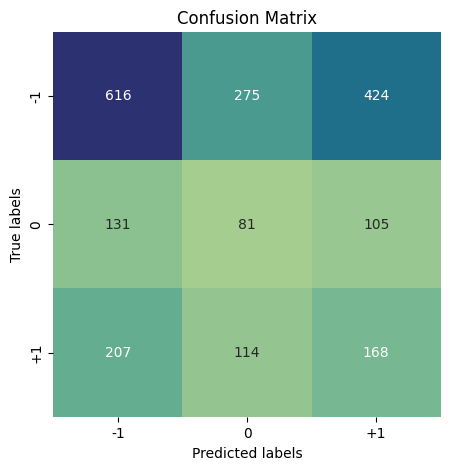

In [96]:
print(classification_report(y_test, y_pred_DT))
accuracy = accuracy_score(y_test, y_pred_DT)
print("Accuracy of Decision Tree:", accuracy)
cm = confusion_matrix(y_test, y_pred_DT)
class_labels = ['-1', '0', '+1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

In [97]:
# kNN
clf = KNeighborsClassifier()
clf.fit(X_train, y_train)
y_pred_knn = clf.predict(X_test)

              precision    recall  f1-score   support

        -1.0       0.61      0.66      0.63      1315
         0.0       0.10      0.07      0.08       317
         1.0       0.22      0.22      0.22       489

    accuracy                           0.47      2121
   macro avg       0.31      0.31      0.31      2121
weighted avg       0.44      0.47      0.45      2121

Accuracy of kNN: 0.4681753889674682


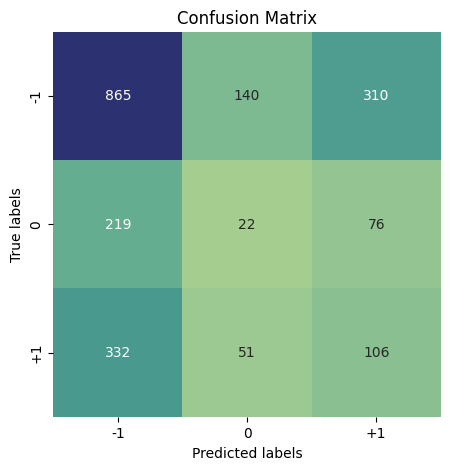

In [98]:
print(classification_report(y_test, y_pred_knn))
accuracy = accuracy_score(y_test, y_pred_knn)
print("Accuracy of kNN:", accuracy)
cm = confusion_matrix(y_test, y_pred_knn)
class_labels = ['-1', '0', '+1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

In [99]:
# SVM
from sklearn.svm import SVC

clf = SVC(kernel='poly', decision_function_shape='ovo', random_state=42)
clf.fit(X_train, y_train+1)
y_pred_svm = clf.predict(X_test)

              precision    recall  f1-score   support

        -1.0       0.92      0.98      0.95      3792
         0.0       0.98      0.85      0.91      1147
         1.0       0.96      0.92      0.94      2426

    accuracy                           0.94      7365
   macro avg       0.95      0.92      0.93      7365
weighted avg       0.94      0.94      0.94      7365

Accuracy of SVM: 0.9406653088934148


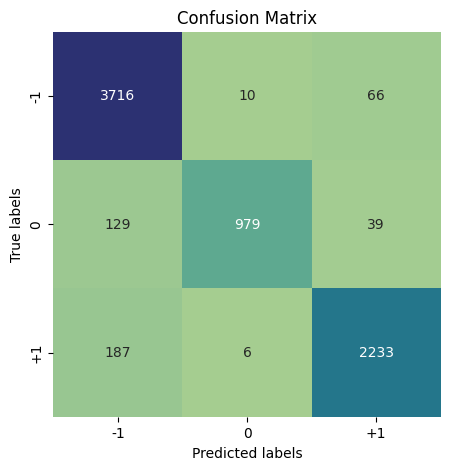

In [100]:
# y_pred_svm2 = clf.predict(X_train)

# print(classification_report(y_train, y_pred_svm2-1))
# accuracy = accuracy_score(y_train, y_pred_svm2-1)
# print("Accuracy of SVM:", accuracy)
# cm = confusion_matrix(y_train, y_pred_svm2-1)
# class_labels = ['-1', '0', '+1']

# plt.figure(figsize=(5, 5))
# sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
#             xticklabels=class_labels, yticklabels=class_labels)
# plt.xlabel("Predicted labels")
# plt.ylabel("True labels")
# plt.title("Confusion Matrix")
# plt.show()

              precision    recall  f1-score   support

        -1.0       0.62      0.89      0.73      1315
         0.0       0.18      0.09      0.12       317
         1.0       0.35      0.06      0.10       489

    accuracy                           0.58      2121
   macro avg       0.38      0.35      0.32      2121
weighted avg       0.49      0.58      0.49      2121

Accuracy of SVM: 0.5770862800565771


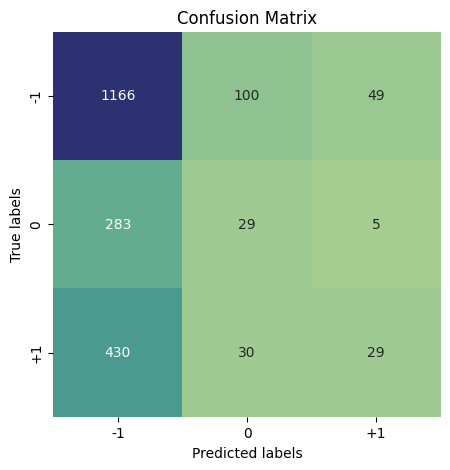

In [101]:
print(classification_report(y_test, y_pred_svm-1))
accuracy = accuracy_score(y_test, y_pred_svm-1)
print("Accuracy of SVM:", accuracy)
cm = confusion_matrix(y_test, y_pred_svm-1)
class_labels = ['-1', '0', '+1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

In [102]:
# Ensemble

y_pred_combine = np.empty(y_test.shape)
y_set = np.vstack((y_test_pred, y_pred_xgb-1, y_pred-1, y_pred_DT, y_pred_knn, y_pred_svm-1))

for j in range(len(y_test)):
  cnt = [0, 0, 0]
  for i in range(y_set.shape[0]):
    if y_set[i][j] == 1: cnt[2] +=1
    elif y_set[i][j] == -1: cnt[0] +=1
    else: cnt[1] += 1
  y_pred_combine[j] = cnt.index(max(cnt))-1


              precision    recall  f1-score   support

        -1.0       0.62      0.95      0.75      1315
         0.0       0.23      0.02      0.03       317
         1.0       0.31      0.06      0.10       489

    accuracy                           0.60      2121
   macro avg       0.39      0.34      0.30      2121
weighted avg       0.49      0.60      0.49      2121

Accuracy of Ensembling: 0.603017444601603


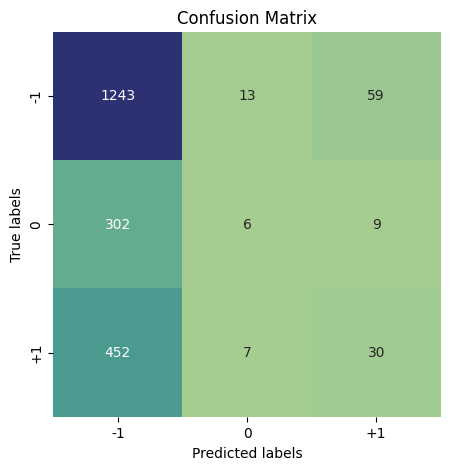

In [104]:
print(classification_report(y_test, y_pred_combine))
accuracy = accuracy_score(y_test, y_pred_combine)
print("Accuracy of Ensembling:", accuracy)
cm = confusion_matrix(y_test, y_pred_combine)
class_labels = ['-1', '0', '+1']

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap="crest", cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

In [55]:
unique_values, counts = np.unique(y_pred_combine, return_counts=True)
value_counts = dict(zip(unique_values, counts))

print("Value counts:", value_counts)

Value counts: {-1.0: 1939, 0.0: 65, 1.0: 117}


In [59]:
tsmc_df[(tsmc_df['date'] >= date_test_start) & (tsmc_df['date'] <= date_test_end)]

,stock_name,stock_symbol,open,high,low,close,volume,date,percent_change,label
441790,台積電,2330,506.0,508.0,498.5,498.5,43684,2022-12-01,0.017347,1.0
443483,台積電,2330,490.0,497.0,490.0,492.5,29909,2022-12-02,-0.012036,-1.0
445669,台積電,2330,491.5,497.5,489.0,489.0,33048,2022-12-05,-0.007107,-1.0
449839,台積電,2330,488.0,489.0,478.0,478.0,44964,2022-12-06,-0.022495,-1.0
451572,台積電,2330,477.0,485.5,475.0,475.0,39979,2022-12-07,-0.006276,0.0
454393,台積電,2330,475.0,475.0,467.0,471.5,28349,2022-12-08,-0.007368,-1.0
454748,台積電,2330,478.0,484.5,476.0,481.5,28904,2022-12-09,0.021209,1.0
458981,台積電,2330,476.5,478.0,473.5,475.0,24064,2022-12-12,-0.013499,-1.0
461416,台積電,2330,473.0,476.0,471.0,471.5,36028,2022-12-13,-0.007368,-1.0
463042,台積電,2330,472.0,480.5,472.0,480.5,35264,2022-12-14,0.019088,1.0


In [61]:
tsmc_df[(tsmc_df['date'] >= date_test_start) & (tsmc_df['date'] <= date_test_end)]['label'].value_counts()

label
-1.0    12
 0.0     6
 1.0     4
Name: count, dtype: int64